<a href="https://colab.research.google.com/github/kphotchara/CatVsDog_Image-Classification/blob/main/cats_vs_dogs_CNN_mini_resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Convolutional Neural Networks (CNN)
### Applied to Cats vs Dogs Dataset (microsoft/cats_vs_dogs)


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
from torchsummary import summary
from PIL import Image
import numpy as np

### 1. Load Dataset

In [ ]:
from datasets import load_dataset

ds = load_dataset("microsoft/cats_vs_dogs")
print(ds)
print(f"\nTotal examples: {len(ds['train'])}")
print(f"Features: {ds['train'].features}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/330M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/391M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23410 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 23410
    })
})

Total examples: 23410
Features: {'image': Image(mode=None, decode=True), 'labels': ClassLabel(names=['cat', 'dog'])}


### 2. Visualize Sample Images

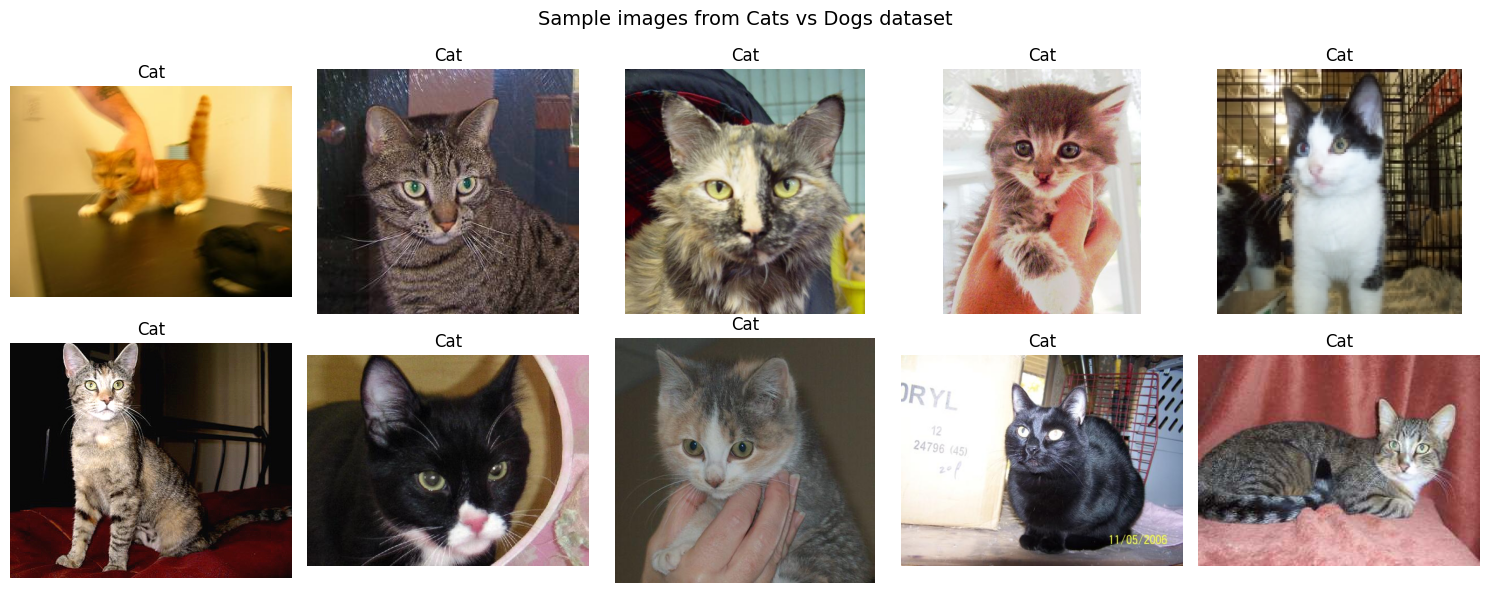

In [ ]:
label_map = {0: 'Cat', 1: 'Dog'}

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    sample = ds['train'][i]
    ax.imshow(sample['image'])
    ax.set_title(label_map[sample['labels']])
    ax.axis('off')
plt.suptitle('Sample images from Cats vs Dogs dataset', fontsize=14)
plt.tight_layout()
plt.show()

### 3. Prepare Data

In [ ]:
# =========================
# TRANSFORMS
# =========================
# Train: เพิ่ม data augmentation เพื่อป้องกัน overfitting
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Val/Test: แค่ resize และ normalize
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# =========================
# TRANSFORM FUNCTIONS FOR HuggingFace dataset
# with_transform() จะ apply ทีละ sample (ไม่ใช่ batch)
# =========================

def apply_train_transform(example_batch):
    images = []

    for img in example_batch['image']:
        if isinstance(img, Image.Image):
            img = img.convert('RGB')
        else:
            img = Image.fromarray(np.array(img)).convert('RGB')

        images.append(train_transform(img))

    example_batch['image'] = images
    return example_batch


def apply_test_transform(example_batch):
    images = []

    for img in example_batch['image']:
        if isinstance(img, Image.Image):
            img = img.convert('RGB')
        else:
            img = Image.fromarray(np.array(img)).convert('RGB')

        images.append(test_transform(img))

    example_batch['image'] = images
    return example_batch

# =========================
# SPLIT INDICES
# =========================
full_dataset = ds['train']
datasize = len(full_dataset)  # 23410

num_train = int(datasize * 0.8)   # ~18728
num_val   = int(datasize * 0.1)   # ~2341
num_test  = datasize - num_train - num_val  # ~2341

generator1 = torch.Generator().manual_seed(42)
indices = torch.randperm(datasize, generator=generator1)

train_idx = indices[:num_train]
val_idx   = indices[num_train:num_train + num_val]
test_idx  = indices[num_train + num_val:]

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

# =========================
# CREATE DATASETS WITH TRANSFORMS
# =========================
train_dataset = full_dataset.with_transform(apply_train_transform)
val_dataset   = full_dataset.with_transform(apply_test_transform)
test_dataset  = full_dataset.with_transform(apply_test_transform)

train_data = Subset(train_dataset, train_idx.tolist())
val_data   = Subset(val_dataset,   val_idx.tolist())
test_data  = Subset(test_dataset,  test_idx.tolist())

# =========================
# COLLATE FUNCTION
# HuggingFace dataset คืน dict ดังนั้น DataLoader
# ต้องการ custom collate เพื่อแยก image และ labels
# =========================
def collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    labels = torch.tensor([item['labels'] for item in batch], dtype=torch.long)
    return images, labels

# =========================
# DATALOADER
# =========================
batch_size = 64

train_dataloader = DataLoader(train_data, batch_size=batch_size,
                              shuffle=True,  collate_fn=collate_fn, num_workers=2)
val_dataloader   = DataLoader(val_data,   batch_size=batch_size,
                              shuffle=False, collate_fn=collate_fn, num_workers=2)
test_dataloader  = DataLoader(test_data,  batch_size=batch_size,
                              shuffle=False, collate_fn=collate_fn, num_workers=2)

# ตรวจสอบ shape
for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape}, dtype: {y.dtype}")
    print(f"Labels in batch: {y[:10]}")
    break

Train: 18728, Val: 2341, Test: 2341
Shape of X [N, C, H, W]: torch.Size([64, 3, 224, 224])
Shape of y: torch.Size([64]), dtype: torch.int64
Labels in batch: tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 1])


### 4. Define CNN Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"


# =========================================
# Residual Block
# =========================================
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
        )

        # Skip connection
        self.shortcut = nn.Sequential()

        # ถ้า dimension ไม่เท่ากัน
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.conv(x)
        out += self.shortcut(x)
        out = F.relu(out)
        return out


# =========================================
# ResNet-like CNN
# =========================================
class MiniResNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # Initial Conv
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Residual layers
        self.layer1 = ResidualBlock(32, 32)
        self.layer2 = ResidualBlock(32, 64, stride=2)
        self.layer3 = ResidualBlock(64, 128, stride=2)

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.gap(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x


model = MiniResNet().to(device)

print(model)
summary(model, input_size=(3, 224, 224))

MiniResNet(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): ResidualBlock(
    (conv): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (shortcut): Sequential()
  )
  (layer2): ResidualBlock(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_

In [ ]:
# Loss และ Optimizer
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Learning rate scheduler (ลด lr เมื่อ val loss ไม่ดีขึ้น)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

### 5. Training Loop

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch % 100 == 0:
            loss_val, current = loss.item(), batch * len(X)
            print(f"  loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")

    return total_loss / len(dataloader)


def evaluate(dataloader, model, loss_fn, split_name="Val"):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            total_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    total_loss /= num_batches
    accuracy = correct / size
    print(f"  {split_name} Accuracy: {(100*accuracy):>0.1f}%,  Avg loss: {total_loss:>8f}")
    return total_loss, accuracy


# =========================
# TRAIN
# =========================
epochs = 30
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

best_val_loss = float('inf')

for t in range(epochs):
    print(f"\nEpoch {t+1}/{epochs}")
    print("-" * 40)
    train_loss = train(train_dataloader, model, loss_fn, optimizer)
    val_loss, val_acc = evaluate(val_dataloader, model, loss_fn, "Val")

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  >>> Best model saved (val_loss={val_loss:.4f})")

print("\nDone!")


Epoch 1/30
----------------------------------------
  loss: 0.666133  [    0/18728]
  loss: 0.595685  [ 6400/18728]
  loss: 0.541047  [12800/18728]
  Val Accuracy: 57.5%,  Avg loss: 0.705967
  >>> Best model saved (val_loss=0.7060)

Epoch 2/30
----------------------------------------
  loss: 0.520393  [    0/18728]
  loss: 0.544345  [ 6400/18728]
  loss: 0.502820  [12800/18728]
  Val Accuracy: 60.2%,  Avg loss: 0.752811

Epoch 3/30
----------------------------------------
  loss: 0.527331  [    0/18728]
  loss: 0.569375  [ 6400/18728]
  loss: 0.403255  [12800/18728]
  Val Accuracy: 69.8%,  Avg loss: 0.701472
  >>> Best model saved (val_loss=0.7015)

Epoch 4/30
----------------------------------------
  loss: 0.429674  [    0/18728]
  loss: 0.517330  [ 6400/18728]
  loss: 0.297173  [12800/18728]
  Val Accuracy: 77.6%,  Avg loss: 0.476895
  >>> Best model saved (val_loss=0.4769)

Epoch 5/30
----------------------------------------
  loss: 0.528576  [    0/18728]
  loss: 0.408882  [ 6400

### 6. Plot Training History

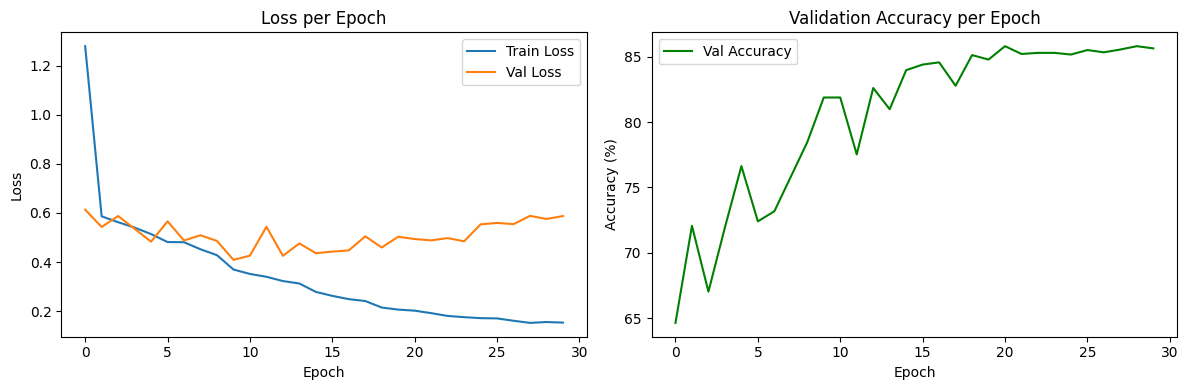

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss per Epoch')
ax1.legend()

ax2.plot([a * 100 for a in history['val_acc']], color='green', label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy per Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

### 7. Test Evaluation

In [ ]:
# โหลด best model แล้วทดสอบบน test set
best_model = MiniResNet().to(device)
best_model.load_state_dict(torch.load("best_model.pth"))

print("=" * 40)
print("Final Test Evaluation")
print("=" * 40)
test_loss, test_acc = evaluate(test_dataloader, best_model, loss_fn, "Test")

Final Test Evaluation
  Test Accuracy: 92.3%,  Avg loss: 0.248396


### 8. Inference — Visualize Predictions

/tmp/ipykernel_3116/3106050871.py:42: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3116/3106050871.py:43: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.savefig('predictions.png', dpi=150)


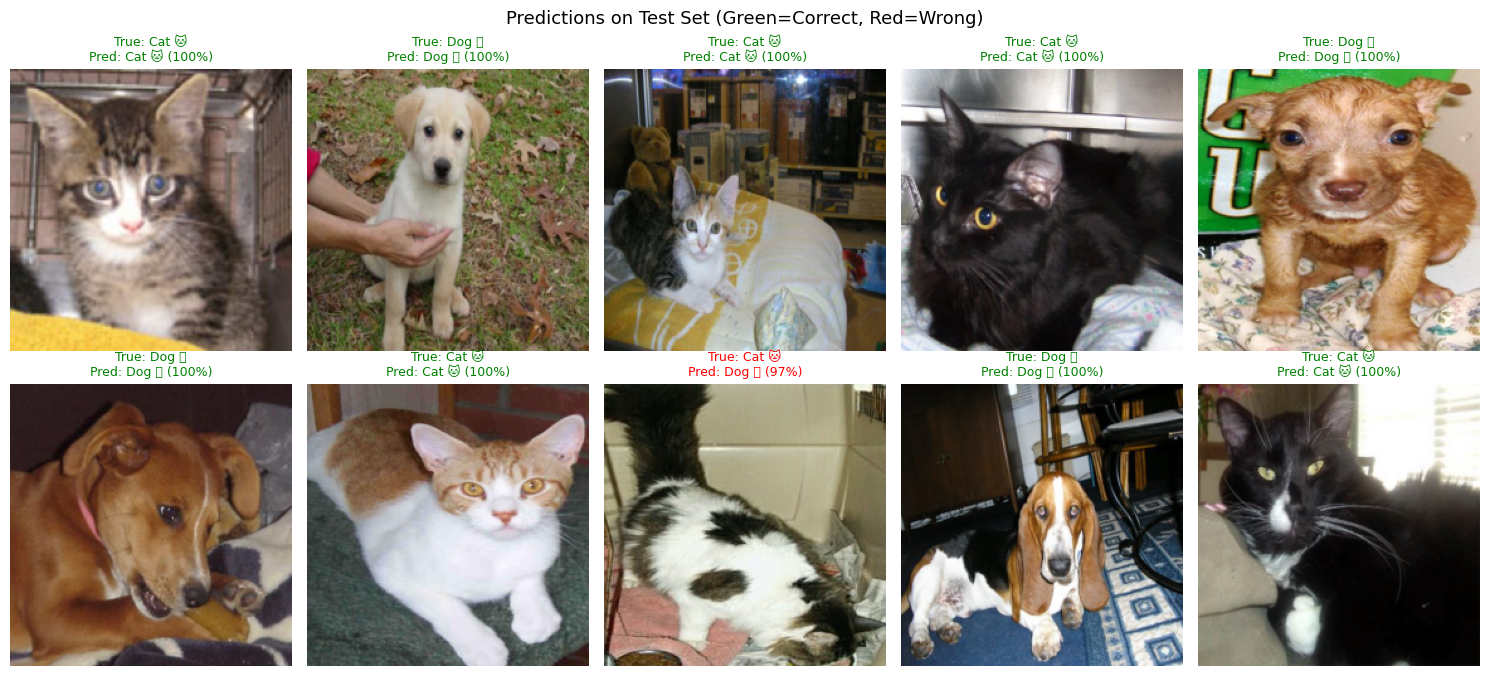

In [ ]:
label_map = {0: 'Cat 🐱', 1: 'Dog 🐶'}

best_model.eval()

# ดึงภาพจาก test set มาแสดงพร้อม prediction
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

sample_indices = test_idx[:10].tolist()

for i, ax in enumerate(axes.flatten()):
    sample = test_dataset[sample_indices[i]]

    img_tensor = sample['image'].unsqueeze(0).to(device)
    true_label = sample['labels']

    with torch.no_grad():
        output = best_model(img_tensor)
        pred_label = output.argmax(1).item()
        confidence = F.softmax(output, dim=1)[0][pred_label].item()

    # แสดงภาพแบบไม่ denormalize
    img_show = sample['image'].permute(1, 2, 0).cpu().numpy()

    ax.imshow(img_show)

    color = 'green' if pred_label == true_label else 'red'

    ax.set_title(
        f"True: {label_map[true_label]}\n"
        f"Pred: {label_map[pred_label]} ({confidence:.0%})",
        color=color,
        fontsize=9
    )

    ax.axis('off')

plt.suptitle(
    'Predictions on Test Set (Green=Correct, Red=Wrong)',
    fontsize=13
)

plt.tight_layout()
plt.savefig('predictions.png', dpi=150)
plt.show()

### 9. Save Final Model

In [ ]:
torch.save(best_model.state_dict(), "cats_vs_dogs_model.pth")
print("Model saved to cats_vs_dogs_model.pth")
print(f"Final Test Accuracy: {test_acc*100:.1f}%")

Model saved to cats_vs_dogs_model.pth
Final Test Accuracy: 92.3%
